# 5 · Order flow imbalance: what actually moves the price?

**The question:** over a short interval, what explains the change in the mid price?

The obvious answer is "trades: more buying pushes the price up". Cont, Kukanov & Stoikov (2014, *"The
price impact of order book events"*) showed a better answer: look at **all** order-book events at the best
quotes, not just trades. A cancellation at the ask is as bullish as a market buy of the same size: both remove
sell liquidity. A new limit buy at the bid adds buying pressure without any trade happening.

They define **order flow imbalance (OFI)** by adding up, over an interval, the signed size changes at the
best bid and ask (see `ofi_events` in `micro/book.py` for the exact rule and its derivation). Their model is a
linear regression:

$$\Delta \text{mid}_k = \alpha + \beta \cdot \text{OFI}_k + \varepsilon_k, \qquad \beta \approx \frac{c}{\text{depth}}$$

The intuition for β ∝ 1/depth: if 10 BTC rests at each best quote, it takes about 10 BTC of net pressure to
push the price one tick. If 1 BTC rests there, it takes 1 BTC.

This chapter is also our first serious **regression** chapter: R², t-statistics, and why we need Newey–West
standard errors.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from micro.data import load_quotes, load_trades, aggregate_trades
from micro.book import mid, to_ms, ofi_events, sum_in_buckets, resample_last, time_grid
from micro.stats import ols, loglog_slope
from micro.plotting import style, save, BLUE, ORANGE, GREEN, GREY

style()
quotes = load_quotes()
orders = aggregate_trades(load_trades())
qts, m = to_ms(quotes.ts), mid(quotes)
e = ofi_events(quotes.bid, quotes.bid_qty, quotes.ask, quotes.ask_qty)   # one value per book update (BTC)
ots = to_ms(orders.ts)
signed_volume = orders.sign.to_numpy() * orders.qty.to_numpy()

print("OFI contributions of the first 8 book updates (BTC):", e[:8].round(3))

OFI contributions of the first 8 book updates (BTC): [ 0.000e+00  9.860e-01  1.140e-01  2.035e+00 -2.000e-03  2.458e+00
 -9.860e-01  1.000e-01]


## Build interval data

For an interval length (1 s, 10 s, 1 min) we sum, within each interval:
- **OFI**: sum of `e` over book updates
- **TFI** (trade flow imbalance): buy volume − sell volume, from aggressive orders only

and compute Δmid = mid at the end − mid at the start.

In [2]:
def intervals(freq):
    grid = time_grid(qts[0], qts[-1], freq)
    df = pd.DataFrame({
        "dmid": np.diff(resample_last(qts, m, grid)),
        "ofi": sum_in_buckets(qts, e, grid),
        "tfi": sum_in_buckets(ots, signed_volume, grid),
    })
    return df.dropna()

data = {f: intervals(f) for f in ["1s", "10s", "1min"]}
data["10s"].describe().round(3)

,dmid,ofi,tfi
count,8639.000,8639.000,8639.000
mean,-0.060,-4.775,-0.528
std,26.662,138.789,53.904
min,-557.750,-990.803,-1265.622
25%,-11.900,-79.088,-6.535
50%,0.000,-2.885,-0.270
75%,11.600,68.021,5.847
max,283.400,914.395,1138.196


## The regressions

Newey–West (HAC) standard errors: residuals are heteroskedastic (volatility clusters, chapter 0) and
possibly autocorrelated. Plain OLS errors would overstate our precision (chapter 2's warning).

In [3]:
rows = []
for f, df in data.items():
    r_ofi = ols(df.dmid, df.ofi, hac_lags=10, names=["ofi"])
    r_tfi = ols(df.dmid, df.tfi, hac_lags=10, names=["tfi"])
    r_both = ols(df.dmid, df[["ofi", "tfi"]], hac_lags=10, names=["ofi", "tfi"])
    rows.append({"interval": f, "n": len(df),
                 "R2 OFI": r_ofi.r2, "R2 TFI": r_tfi.r2, "R2 both": r_both.r2,
                 "beta OFI (USDT/BTC)": r_ofi.beta[1], "t OFI": r_ofi.t[1]})
print(pd.DataFrame(rows).set_index("interval").round(3))
print("\nFull output, 10-second regression on both:")
print(ols(data["10s"].dmid, data["10s"][["ofi", "tfi"]], hac_lags=10, names=["ofi", "tfi"]))

              n  R2 OFI  R2 TFI  R2 both  beta OFI (USDT/BTC)    t OFI
interval                                                              
1s        86399   0.411   0.331    0.610                0.142  106.513
10s        8639   0.487   0.370    0.699                0.134   47.094
1min       1439   0.399   0.528    0.741                0.117   14.166

Full output, 10-second regression on both:
OLS(n=8,639, R2=0.6991)
        coef  std err     t
const 0.6037    0.149 4.051
ofi   0.1132 0.001981 57.13
tfi    0.234  0.01876 12.47


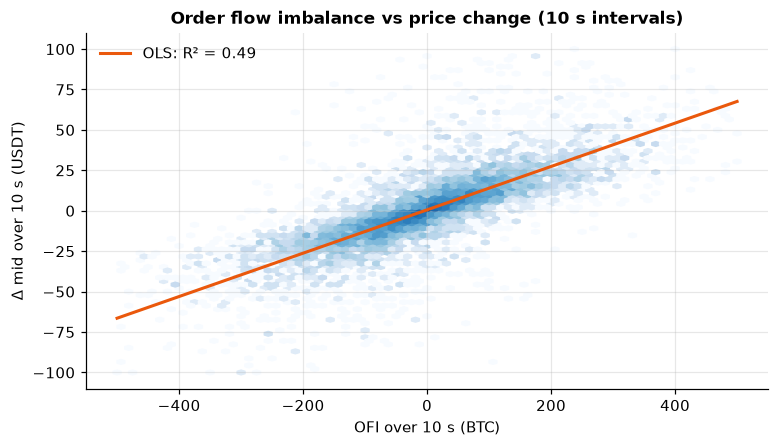

In [4]:
df = data["10s"]
fig, ax = plt.subplots()
hb = ax.hexbin(df.ofi, df.dmid, gridsize=80, bins="log", cmap="Blues", extent=(-500, 500, -100, 100))
r = ols(df.dmid, df.ofi)
xs = np.linspace(-500, 500, 10)
ax.plot(xs, r.beta[0] + r.beta[1] * xs, color=ORANGE, lw=2, label=f"OLS: R² = {r.r2:.2f}")
ax.set(xlabel="OFI over 10 s (BTC)", ylabel="Δ mid over 10 s (USDT)", title="Order flow imbalance vs price change (10 s intervals)")
ax.legend(loc="upper left")
save(fig, "05_ofi_scatter")

- **OFI alone explains about 40–50% of the variance** of mid changes at every horizon. For a single linear
  variable on financial data, that's huge. (CKS found about 65% on average across 50 US stocks.)
- **Trades alone (TFI) explain less** at 1 s and 10 s. Most of the information arrives through quotes:
  cancellations and new limit orders, not trades.
- **Together they reach 60–75%.** In crypto the two carry partly different information. Hidden liquidity
  and the many fills that happen inside a millisecond make L1 quote changes an imperfect record of what trades did.
- t-statistics are enormous even with robust errors. That's because n is huge, not because the effect is big.
  **With 86,400 observations everything is "significant"; R² and effect sizes are what matter.**

## The catch: this is *explanation*, not *prediction*

These regressions use OFI and Δmid **over the same interval**. That tells us *how* prices move (through
order flow), but you can't trade on it. You'd need to know the OFI before it happens. Does OFI in one interval
predict the *next* interval's price change?

In [5]:
for f, df in data.items():
    nxt = ols(df.dmid.to_numpy()[1:], df.ofi.to_numpy()[:-1], hac_lags=10)
    print(f"{f:>4}: R² of next-interval Δmid on this interval's OFI = {nxt.r2:.4f}  (t = {nxt.t[1]:.1f})")

  1s: R² of next-interval Δmid on this interval's OFI = 0.0198  (t = 31.2)
 10s: R² of next-interval Δmid on this interval's OFI = 0.0015  (t = 3.4)
1min: R² of next-interval Δmid on this interval's OFI = 0.0000  (t = 0.2)


Predictive power collapses: about 2% at 1 s, essentially zero at one minute. The market digests order flow
within a second or two. That's the efficiency that HFT firms both create and compete over: the only
predictability left is at horizons where you need to be very fast to act on it (chapter 9 tests whether it
survives trading costs).

## Does β really scale like 1/depth?

CKS's model says the price impact of one unit of OFI should be inversely proportional to how much
liquidity sits at the best quotes. Test it: split the day into 30-minute windows, estimate β in each, and
compare with the average depth at the touch.

log-log slope = -1.19  (CKS model predicts about -1)


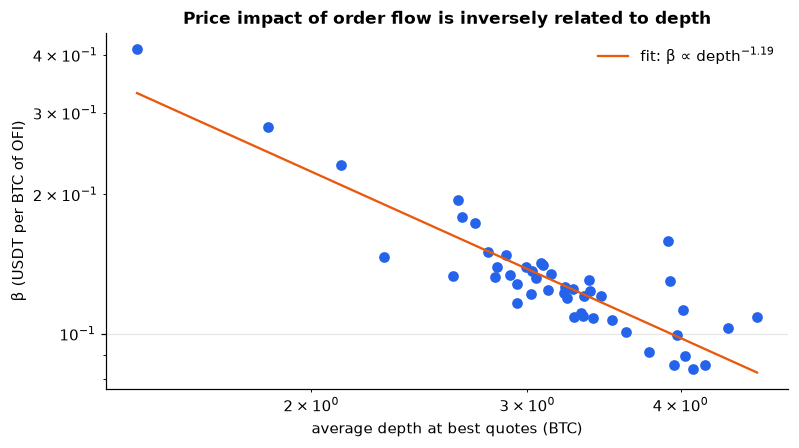

In [6]:
window = quotes.ts.dt.floor("30min").to_numpy()
depth = (quotes.bid_qty + quotes.ask_qty).to_numpy() / 2
depth_by_window = pd.Series(depth).groupby(window).mean()

df1 = data["1s"].copy()
grid = time_grid(qts[0], qts[-1], "1s")
df1["window"] = pd.to_datetime(grid[:-1][data["1s"].index]).floor("30min")
betas = df1.groupby("window").apply(lambda g: ols(g.dmid, g.ofi).beta[1])
betas.index = betas.index.tz_localize("UTC")
both = pd.DataFrame({"beta": betas, "depth": depth_by_window}).dropna()
slope, c = loglog_slope(both.depth, both.beta)

fig, ax = plt.subplots()
ax.loglog(both.depth, both.beta, "o", color=BLUE)
xs = np.logspace(np.log10(both.depth.min()), np.log10(both.depth.max()), 10)
ax.loglog(xs, c * xs**slope, color=ORANGE, label=f"fit: β ∝ depth$^{{{slope:.2f}}}$")
ax.set(xlabel="average depth at best quotes (BTC)", ylabel="β (USDT per BTC of OFI)", title="Price impact of order flow is inversely related to depth")
ax.legend()
save(fig, "05_beta_vs_depth")
print(f"log-log slope = {slope:.2f}  (CKS model predicts about -1)")

Each dot is a half-hour window. When the book is thin, a unit of OFI moves the price more. The slope is
negative, as the theory predicts. Compare its size with −1 when you run it: CKS found exponents close to 1
for US stocks. A deviation tells you depth at the touch isn't the whole story. Deeper levels matter too (chapter 10).

---
### Interview angle

<details><summary><b>"A large limit sell order gets cancelled at the best ask. What happens to your fair value?"</b></summary>

It goes up. Removing sell-side liquidity is buying pressure, just like a market buy of the same size
(it raises OFI). And cancellations often carry information: the seller changed their mind.
</details>

<details><summary><b>"Your regression has a t-stat of 100. Is it a good model?"</b></summary>

Not necessarily. With huge n, tiny effects get huge t-stats. Look at R², the out-of-sample performance, and
whether the standard errors are right (overlapping data or heteroskedasticity → use Newey–West). And
"explains" ≠ "predicts": a contemporaneous R² of 0.5 can coexist with zero predictive power.
</details>

<details><summary><b>"Why use Newey–West standard errors?"</b></summary>

OLS standard errors assume independent residuals with constant variance. Financial residuals have
volatility clustering (heteroskedasticity) and often autocorrelation (especially with overlapping intervals).
Newey–West estimates the variance of the coefficient using the residuals' actual autocovariances up to some
lag, weighted to stay positive definite. See `micro/stats.py:ols` and its test against statsmodels.
</details>

### Try this yourself
1. Add the **lagged** OFI as a second regressor in the contemporaneous 1 s regression. Is it significant? What sign? (Hint: reversal or continuation?)
2. Replace the linear OFI with `np.sign(ofi) * np.sqrt(abs(ofi))`. Does a concave transform improve R²?